# Online Retail Market Basket Analysis using Apriori



## 1. Business Problem Statement
An online retail company wants to understand which products are frequently bought together to improve cross-selling, bundling, and recommendation strategies.

## 2. Dataset Overview
- Source: Kaggle – Online Retail Dataset
- Transactions from a UK-based online retailer (2010–2011)
- Transaction unit: InvoiceNo

## 3. Load and Clean Data

In [10]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)






import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

# Remove missing descriptions
df = df.dropna(subset=["Description"])

# Remove cancelled invoices
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove non-positive quantities
df = df[df["Quantity"] > 0]

# Focus on UK transactions
df = df[df["Country"] == "United Kingdom"]

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 4. Basket Preparation (One-Hot Encoding)

In [18]:

basket = (
    df.groupby(["Invoice", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

def encode_units(x):
    return 1 if x > 0 else 0

basket = basket.applymap(encode_units)

basket.head(20)


/tmp/ipython-input-3264604820.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(encode_units)


Description,22719,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,dotcom email,eurobargain invc/credit,found,found again,mailout,mailout addition,temp,tk maxx mix up with pink,update,wrong invc
Invoice,,,,,,,,,,,,,,,,,,,,,
538147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538151,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538154,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538156,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
538157,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


* groupby(["Invoice", "Description"])["Quantity"].sum()

Groups data by Invoice (transaction) and Product

Sums quantity of each product per invoice

* .unstack()

Converts product names into columns

Each row becomes one invoice (basket)

* .fillna(0)

Replaces missing values with 0

Means item not purchased in that invoice

* encode_units(x)

Converts quantity to binary:

1 → item purchased

0 → item not purchased

* applymap(encode_units)

Applies binary encoding to every cell

* basket.tail(20)

Displays last 20 invoices

Rows = invoices, columns = products, values = 0/1

## 5. Apply Apriori Algorithm

In [12]:

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()


,support,itemsets
0,0.024921,(12 PENCILS SMALL TUBE SKULL)
1,0.022284,(3 HEARTS HANGING DECORATION RUSTIC)
2,0.038623,(6 RIBBONS RUSTIC CHARM)
3,0.022439,(60 CAKE CASES VINTAGE CHRISTMAS)
4,0.062872,(60 TEATIME FAIRY CAKE CASES)


* from mlxtend.frequent_patterns import apriori

Imports the Apriori algorithm for association rule mining

* apriori(basket, ...)

Applies Apriori on the transaction–item matrix

* min_support=0.02

Keeps itemsets that appear in at least 2% of all transactions

* use_colnames=True

Displays actual product names instead of column indices

* frequent_itemsets

Output dataframe containing:

itemsets → product combinations

support → how frequently they occur

* frequent_itemsets.head()






 Shows first few frequent itemsets

## 6. Generate Association Rules

In [13]:

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(60 TEATIME FAIRY CAKE CASES),(72 SWEETHEART FAIRY CAKE CASES),0.062872,0.041518,0.022594,0.359375,8.655880,1.0,0.019984,1.496167,0.943810,0.276233,0.331625,0.451792
1,(72 SWEETHEART FAIRY CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.041518,0.062872,0.022594,0.544209,8.655880,1.0,0.019984,2.056049,0.922784,0.276233,0.513630,0.451792
2,(60 TEATIME FAIRY CAKE CASES),(PACK OF 60 PINK PAISLEY CAKE CASES),0.062872,0.053927,0.027661,0.439967,8.158585,1.0,0.024271,1.689317,0.936296,0.310325,0.408045,0.476455
3,(PACK OF 60 PINK PAISLEY CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.053927,0.062872,0.027661,0.512943,8.158585,1.0,0.024271,1.924065,0.927444,0.310325,0.480267,0.476455
4,(PACK OF 72 RETRO SPOT CAKE CASES),(60 TEATIME FAIRY CAKE CASES),0.064164,0.062872,0.028282,0.440774,7.010692,1.0,0.024248,1.675758,0.916144,0.286387,0.403255,0.445305


* from mlxtend.frequent_patterns import association_rules

Imports function to generate IF–THEN rules from frequent itemsets

* association_rules(frequent_itemsets, ...)

Creates rules from previously found frequent itemsets

* metric="lift"

Uses lift to evaluate rule strength

* min_threshold=1

Keeps rules where:

lift ≥ 1 → items are positively associated

rules

Output dataframe containing:

antecedents → IF part

consequents → THEN part

support, confidence, lift

## 7. Filter Strong Association Rules

In [14]:

strong_rules = rules[
    (rules["confidence"] > 0.6) &
    (rules["lift"] > 1.2)
].sort_values(by="lift", ascending=False)

strong_rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,(SINGLE HEART ZINC T-LIGHT HOLDER),(HANGING HEART ZINC T-LIGHT HOLDER),0.032625,0.046430,0.020423,0.625990,13.482497,1.0,0.018908,2.549588,0.957054,0.348325,0.607780,0.532928
49,(VINTAGE HEADS AND TAILS CARD GAME ),(VINTAGE SNAP CARDS),0.034952,0.049170,0.022129,0.633136,12.876430,1.0,0.020411,2.591778,0.955744,0.356964,0.614165,0.541594
54,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.047516,0.057288,0.030609,0.644178,11.244635,1.0,0.027886,2.649397,0.956518,0.412544,0.622556,0.589237
45,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.049480,0.079779,0.039140,0.791014,9.915096,1.0,0.035192,4.403259,0.945950,0.434309,0.772895,0.640808
41,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.052324,0.165710,0.037899,0.724308,4.370935,1.0,0.029228,3.026170,0.813797,0.210390,0.669549,0.476507


Visualize Top Frequent Items

We will,

Visualizes the 10 most purchased items.
Helps understand popular products in the dataset.

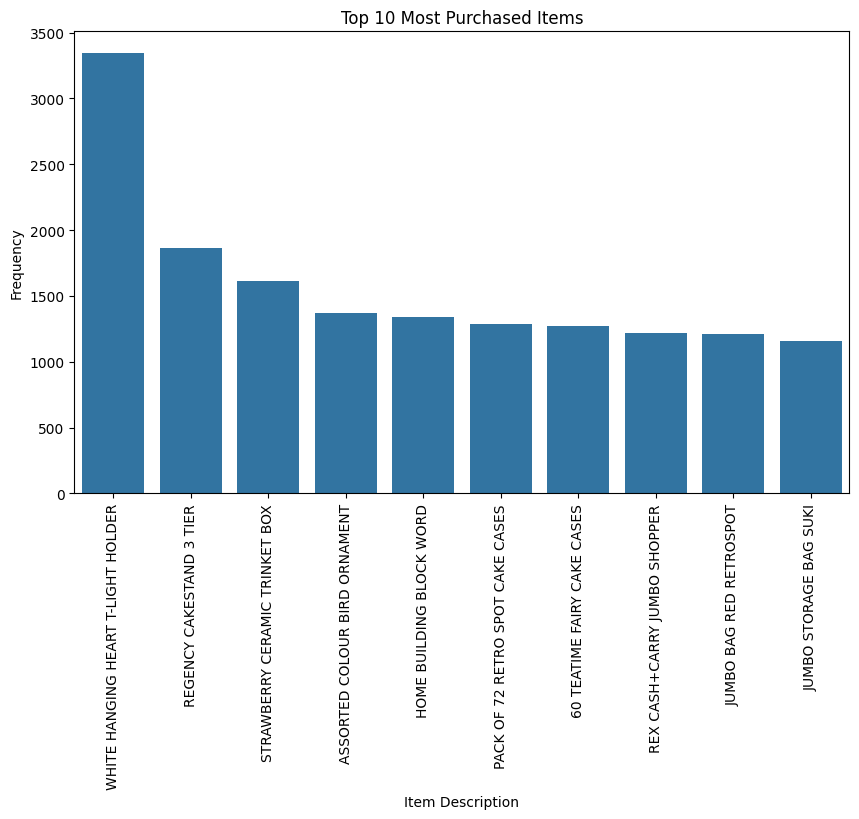

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns
item_frequencies = df["Description"].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=item_frequencies.index, y=item_frequencies.values)
plt.title("Top 10 Most Purchased Items")
plt.xlabel("Item Description")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()





## 8. Key Takeaways
- Lift > 1 indicates strong associations
- High-confidence rules are useful for recommendations
- Apriori provides interpretable insights for business decisions